<h2><center>Detect diabetic retinopathy to stop blindness before it's too late</center></h2>
<center><img src="https://raw.githubusercontent.com/dimitreOliveira/MachineLearning/master/Kaggle/APTOS%202019%20Blindness%20Detection/aux_img.png"></center>
##### Image source: http://cceyemd.com/diabetes-and-eye-exams/

In [1]:
# Helper libraries
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
%matplotlib inline
print(tensorflow.__version__)

2025-09-12 08:33:42.339562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757666022.698082      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757666022.797206      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0


## Read in the training and test data

In [2]:
import os
import pandas as pd

# Đọc CSV nhãn
train_df = pd.read_csv('/kaggle/input/dataset/train.csv')

# Thư mục chứa ảnh
img_dir = '/kaggle/input/dataset/all_images/kaggle/working/all_images'

# Hàm tìm đúng file extension
def find_image_file(id_code):
    for ext in ['.png', '.jpeg', '.jpg']:
        path = os.path.join(img_dir, id_code + ext)
        if os.path.exists(path):
            return id_code + ext
    return None  # nếu không tìm thấy

# Tìm ảnh tương ứng và lọc bỏ ảnh không tồn tại
train_df['file_name'] = train_df['id_code'].apply(find_image_file)
train_df = train_df[train_df['file_name'].notnull()].reset_index(drop=True)


stage1_df = train_df.copy()

stage1_df['diagnosis'] = stage1_df['diagnosis'].astype(str)

print("Stage 1 label distribution:")
print(stage1_df['diagnosis'].value_counts())


# Áp dụng cho test
test_df = pd.read_csv('/kaggle/input/aptos2019/test.csv')
test_img_dir = '/kaggle/input/aptos2019/test_images'
test_df['id_code'] = test_df['id_code'].apply(lambda x: x + '.png' if os.path.exists(os.path.join(test_img_dir, x + '.png')) 
                                              else x + '.jpeg')

# Số lớp mới và nhãn mô tả
num_classes = stage1_df['diagnosis'].nunique()
diag_text = ['Normal', 'Mild', 'Moderate', 'Severe'',Proliferative']

print(f"Số lớp sau khi gộp: {num_classes}")
print(train_df.head())


Stage 1 label distribution:
diagnosis
0    1796
1    1069
3    1062
4    1003
2     995
Name: count, dtype: int64
Số lớp sau khi gộp: 5
        id_code  diagnosis         file_name
0  000c1434d8d7          2  000c1434d8d7.png
1  001639a390f0          4  001639a390f0.png
2  0024cdab0c1e          1  0024cdab0c1e.png
3  002c21358ce6          0  002c21358ce6.png
4  005b95c28852          0  005b95c28852.png


In [3]:
# Lọc lớp 0
class0_df = stage1_df[stage1_df['diagnosis'] == "0"]

# Lấy ngẫu nhiên 1000 ảnh lớp 0 (nếu ít hơn thì lấy hết)
class0_sample = class0_df.sample(n=1100, random_state=42) if len(class0_df) >= 1100 else class0_df

# Giữ nguyên các lớp khác
other_classes_df = stage1_df[stage1_df['diagnosis'] != "0"]

# Ghép lại -> stage1_df mới
stage1_df = pd.concat([class0_sample, other_classes_df]).reset_index(drop=True)

print("Phân bố nhãn sau khi điều chỉnh:")
print(stage1_df['diagnosis'].value_counts())


Phân bố nhãn sau khi điều chỉnh:
diagnosis
0    1100
1    1069
3    1062
4    1003
2     995
Name: count, dtype: int64


### Look at some raw images

### Graph out the class frequency

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(df, label_col="diagnosis", title="Class Frequency"):
    """
    Hiển thị số lượng ảnh theo từng nhãn trong dataframe.

    Args:
        df: pandas.DataFrame chứa dữ liệu
        label_col: tên cột chứa nhãn
        title: tiêu đề biểu đồ
    """
    unique, counts = np.unique(df[label_col], return_counts=True)
    
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c} images")

    plt.bar(unique, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Frequency")
    plt.xticks(unique)  # đảm bảo hiển thị đúng nhãn
    plt.show()


Class 0: 1100 images
Class 1: 1069 images
Class 2: 995 images
Class 3: 1062 images
Class 4: 1003 images


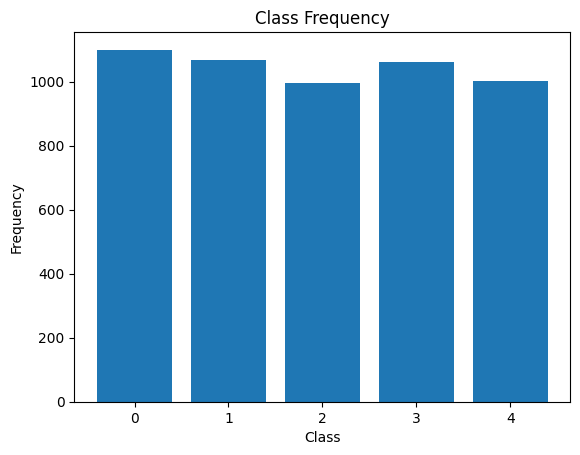

In [9]:
plot_class_distribution(stage1_df, label_col="diagnosis")

### Calculate class weights to help with training on the unbalanced data set.[](http://) 

In [4]:
from sklearn.utils import class_weight

classes = np.unique(stage1_df['diagnosis'])

sklearn_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',   # ← tham số phải đặt tên
    classes=classes,
    y=stage1_df['diagnosis']
)

print(sklearn_class_weights)
class_weights_dict = dict(zip(classes, sklearn_class_weights))

[0.95072727 0.97829747 1.05105528 0.98474576 1.04267198]


## Load a model

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D ,Concatenate
from tensorflow.keras.applications import DenseNet121, ResNet50, InceptionV3, Xception, ResNet50V2, EfficientNetB4,ResNet101
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras import layers, Model, Input
import tensorflow as tf

class CBAM(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.ratio = ratio
        self.channel_dense1 = None
        self.channel_dense2 = None
        self.spatial_conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')

    def build(self, input_shape):
        channel = input_shape[-1]
        self.channel_dense1 = layers.Dense(channel // self.ratio, activation='relu', kernel_initializer='he_normal')
        self.channel_dense2 = layers.Dense(channel, kernel_initializer='he_normal')
        super(CBAM, self).build(input_shape)

    def call(self, x):
        # Channel attention
        avg_pool = tf.reduce_mean(x, axis=[1,2], keepdims=True)
        max_pool = tf.reduce_max(x, axis=[1,2], keepdims=True)
        avg_out = self.channel_dense2(self.channel_dense1(avg_pool))
        max_out = self.channel_dense2(self.channel_dense1(max_pool))
        scale = tf.nn.sigmoid(avg_out + max_out)
        x = x * scale

        # Spatial attention
        avg_pool_spatial = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool_spatial, max_pool_spatial], axis=-1)
        scale_spatial = self.spatial_conv(concat)
        x = x * scale_spatial
        return x

In [6]:

def create_resnet_effnet_cbam(input_shape, n_out):
    inputs = Input(shape=input_shape)

    # ResNet branch lấy feature map cuối cùng
    resnet_base = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)
    resnet_feat = resnet_base.get_layer("conv5_block3_out").output   # (7,7,2048)
    resnet_feat = CBAM(ratio=8)(resnet_feat)  # CBAM trên feature map

    # EfficientNet branch lấy feature map cuối cùng
    effnet_base = EfficientNetB4(weights="imagenet", include_top=False, input_tensor=inputs)
    effnet_feat = effnet_base.get_layer("top_conv").output           # (7,7,1792)
    effnet_feat = CBAM(ratio=8)(effnet_feat)

    # Gộp feature maps
    concat = Concatenate()([resnet_feat, effnet_feat])   # (7,7,2048+1792)

    # Global pooling
    gap = GlobalAveragePooling2D()(concat)
    x = Dropout(0.5)(gap)
    x = Dense(2048, activation = 'relu')(x)
    x = Dropout(0.5)(x)
    # Classifier
    outputs = Dense(n_out, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model



In [7]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
model = create_resnet_effnet_cbam(input_shape = (IMAGE_HEIGHT, IMAGE_WIDTH, 3), n_out = num_classes)


I0000 00:00:1757666178.814263      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757666178.815008      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Crop and improve lighting condition using Ben Graham's preprocessing method
See: https://www.kaggle.com/ratthachat/aptos-updated-preprocessing-ben-s-cropping

### Look at some preprocessed images

### Change target to a multi-label problem so a class encompasses all the classes before it.
see: https://arxiv.org/abs/0704.1028

### Split into training and validation

In [8]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Chia dataframe thành train_df và val_df
train_df, val_df = train_test_split(stage1_df, test_size=0.2, stratify=stage1_df['diagnosis'], random_state=42)

# Generator cho train (có augment)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=360,
    horizontal_flip=True,
    zoom_range=[0.98, 1.02],
    width_shift_range=0.01,
    height_shift_range=0.01
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=img_dir,
    x_col='file_name',
    y_col='diagnosis',
    target_size=(224,224),
    class_mode='categorical',
    batch_size=16,
    shuffle=True
)

# Generator cho val (chỉ rescale, không augment)
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory=img_dir,
    x_col='file_name',
    y_col='diagnosis',
    target_size=(224,224),
    class_mode='categorical',
    batch_size=16,
    shuffle=False
)

Found 4183 validated image filenames belonging to 5 classes.
Found 1046 validated image filenames belonging to 5 classes.


## Setup training data generator with augmentation

## Set up QWKOptimizerCheckpoint

In [10]:

import numpy as np
import tensorflow as tf
from sklearn.metrics import cohen_kappa_score

# ==========================
# QWK Optimizer
# ==========================
class QWKOptimizer:
    def __init__(self, n_classes):
        self.n_classes = n_classes
        self.thresholds = None

    def _apply_thresholds(self, scores, thresholds):
        thresholds = np.sort(thresholds)  # ép tăng dần
        return np.digitize(scores, thresholds)

    def _qwk_loss(self, thresholds, scores, y_true):
        y_pred = self._apply_thresholds(scores, thresholds)
        return -cohen_kappa_score(y_true, y_pred, weights="quadratic")

    def fit(self, y_true, y_pred_proba):
        # Expected score từ softmax
        scores = (y_pred_proba * np.arange(self.n_classes)).sum(axis=1)

        init_thresholds = np.linspace(0.5, self.n_classes - 1.5, self.n_classes - 1)

        opt = minimize(
            self._qwk_loss,
            init_thresholds,
            args=(scores, y_true),
            method="nelder-mead",
            options={'maxiter': 100, 'disp': False}
        )
        self.thresholds = np.sort(opt.x)
        return self

    def predict(self, y_pred_proba):
        scores = (y_pred_proba * np.arange(self.n_classes)).sum(axis=1)
        return np.digitize(scores, self.thresholds)


# ==========================
# QWK + Checkpoint Callback
# ==========================
class QWKOptimizerCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, val_generator, filepath="best_qwk.h5", n_classes=5, eval_interval=1):
        super().__init__()
        self.val_generator = val_generator
        self.filepath = filepath
        self.best_qwk = -np.inf
        self.n_classes = n_classes
        self.eval_interval = eval_interval

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.eval_interval != 0:
            return

        # Predict on validation
        val_pred_proba = self.model.predict(self.val_generator, verbose=0)
        val_true = self.val_generator.classes

        # Optimize thresholds (ở đây có thể mở rộng thêm grid-search)
        qwk_opt = QWKOptimizer(n_classes=self.n_classes).fit(val_true, val_pred_proba)
        val_pred = qwk_opt.predict(val_pred_proba)

        # Compute QWK
        qwk = cohen_kappa_score(val_true, val_pred, weights="quadratic")
        print(f"\nEpoch {epoch+1}: val_qwk = {qwk:.4f}")

        # Save model if better
        if qwk > self.best_qwk:
            self.best_qwk = qwk
            self.model.save(self.filepath, save_format="h5")
            print(f"✔ Saved new best model with QWK = {qwk:.4f} at {self.filepath}")

        logs["val_qwk"] = qwk

            
qwk_cb = QWKOptimizerCheckpoint(val_generator)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)

# Dùng tất cả GPU (dual GPU nếu có 2 cái)
strategy = tf.distribute.MirroredStrategy()

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [12]:
import tensorflow as tf
from tensorflow.keras import backend as K
from scipy.optimize import minimize
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

WARMUP_EPOCHS = 5
WARMUP_LEARNING_RATE = 1e-3

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    # === Phase 1: Warmup training ===
    model = create_resnet_effnet_cbam(
        input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), 
        n_out=num_classes
    )
    
    for layer in model.layers:
        layer.trainable = False
    for layer in model.layers[-50:]:
        layer.trainable = True
    
    model.compile(
        optimizer=Adam(learning_rate=WARMUP_LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint_ce = ModelCheckpoint(
        "stage1_best_original.h5", monitor="val_accuracy", 
        save_best_only=True, mode="max"
    )
    early_ce = EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    )

    warmup_history = model.fit(
        train_generator,
        class_weight=class_weights_dict,
        steps_per_epoch=train_generator.n // train_generator.batch_size,
        validation_data=val_generator,
        epochs=WARMUP_EPOCHS,
        callbacks=[qwk_cb, early_ce],
        verbose=1
    ).history

    # === Phase 2: Fine-tuning ===
    for layer in model.layers:
        layer.trainable = True
    
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    finetune_history = model.fit(
        train_generator,
        class_weight=class_weights_dict,
        steps_per_epoch=train_generator.n // train_generator.batch_size,
        validation_data=val_generator,
        epochs=20,
        callbacks=[qwk_cb, early_ce],
        verbose=1
    ).history


Epoch 1/5


E0000 00:00:1757666884.723230      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: nan - loss: nan
Epoch 1: val_qwk = 0.2879
261/261 ━━━━━━━━━━━━━━━━━━━━ 178s 495ms/step - accuracy: nan - loss: nan - val_accuracy: 0.3797 - val_loss: 1.4028 - val_qwk: 0.2879
Epoch 2/5
  1/261 ━━━━━━━━━━━━━━━━━━━━ 51s 199ms/step - accuracy: 0.1875 - loss: 1.5539

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_qwk = 0.2873
261/261 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.1875 - loss: 1.5539 - val_accuracy: 0.3777 - val_loss: 1.4040 - val_qwk: 0.2873
Epoch 3/5
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: nan - loss: nan
Epoch 3: val_qwk = 0.1836
261/261 ━━━━━━━━━━━━━━━━━━━━ 77s 297ms/step - accuracy: nan - loss: nan - val_accuracy: 0.2972 - val_loss: 1.7235 - val_qwk: 0.1836
Epoch 4/5
  1/261 ━━━━━━━━━━━━━━━━━━━━ 40s 155ms/step - accuracy: 0.3125 - loss: 1.4121

...


Epoch 8: val_qwk = 0.7825
✔ Saved new best model with QWK = 0.7825 at best_qwk.h5
261/261 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.7500 - loss: 0.7168 - val_accuracy: 0.5762 - val_loss: 1.1730 - val_qwk: 0.7825
Epoch 9/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: nan - loss: nan
Epoch 9: val_qwk = 0.4340
261/261 ━━━━━━━━━━━━━━━━━━━━ 156s 597ms/step - accuracy: nan - loss: nan - val_accuracy: 0.3585 - val_loss: 2.1201 - val_qwk: 0.4340
Epoch 10/20
  1/261 ━━━━━━━━━━━━━━━━━━━━ 2:18 534ms/step - accuracy: 0.6250 - loss: 0.8802

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 10: val_qwk = 0.4703
261/261 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.6250 - loss: 0.8802 - val_accuracy: 0.3583 - val_loss: 2.1790 - val_qwk: 0.4703
Epoch 11/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: nan - loss: nan
Epoch 11: val_qwk = 0.6582
261/261 ━━━━━━━━━━━━━━━━━━━━ 156s 596ms/step - accuracy: nan - loss: nan - val_accuracy: 0.4693 - val_loss: 1.3090 - val_qwk: 0.6582
Epoch 12/20
  1/261 ━━━━━━━━━━━━━━━━━━━━ 2:17 529ms/step - accuracy: 0.6250 - loss: 0.8001

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 12: val_qwk = 0.6562
261/261 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.6250 - loss: 0.8001 - val_accuracy: 0.4663 - val_loss: 1.3510 - val_qwk: 0.6562


In [13]:

FINETUNING_EPOCHS = 20
FINETUNING_LEARNING_RATE = 1e-4

    
class SoftmaxFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name="softmax_focal_loss"):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        """
        y_true: one-hot vector
        y_pred: softmax probabilities (after activation)
        """
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)  # tránh log(0)

        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = self.alpha * tf.pow(1 - y_pred, self.gamma)

        loss = tf.reduce_sum(focal_weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss)
        
class BinaryFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, name="binary_focal_loss"):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        """
        y_true: multi-label one-hot (0/1) với sigmoid output
        y_pred: sigmoid probabilities
        """
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)

        # focal loss từng nhãn
        cross_entropy = - (y_true * tf.math.log(y_pred) + 
                           (1 - y_true) * tf.math.log(1 - y_pred))
        focal_weight = (y_true * self.alpha * tf.pow(1 - y_pred, self.gamma) +
                        (1 - y_true) * (1 - self.alpha) * tf.pow(y_pred, self.gamma))

        loss = focal_weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

import math
# Compile with lower LR
with strategy.scope():
    model.load_weights("/kaggle/working/best_qwk.h5", by_name=True, skip_mismatch=True)
    # Make all layers trainable
    for layer in model.layers:
        layer.trainable = True
        
    model.compile(
        optimizer = Adam(learning_rate = FINETUNING_LEARNING_RATE), 
        loss=SoftmaxFocalLoss(gamma=2.0, alpha=0.25),
        metrics = ['accuracy']
    )
    
    # Callbacks
    checkpoint = ModelCheckpoint(
        'blindness_detector_best.keras',   # ✅ đuôi .keras cho full model
        monitor='val_accuracy',
        save_best_only=True,      
        mode='max',
        verbose=1
    )
    
    rlrop = ReduceLROnPlateau(
        monitor = 'val_loss', 
        patience = 3, 
        factor = 0.5, 
        min_lr = 1e-6, 
        verbose = 1
    )
    
    stopping = EarlyStopping(
        monitor = 'val_accuracy', 
        patience = 8, 
        restore_best_weights = True, 
            mode='max',  
        verbose = 1
    )
    
    # ✅ Fix: Disable multiprocessing for stability on Windows
    finetune_history = model.fit(
         train_generator,
        class_weight = class_weights_dict,
        steps_per_epoch = math.ceil(train_generator.n / train_generator.batch_size),
        validation_data = val_generator,
        epochs = FINETUNING_EPOCHS,
        callbacks = [qwk_cb, rlrop, stopping],         
        verbose = 1
    ).history
    model.save("blindness_detector_best.keras")

Epoch 1/20


E0000 00:00:1757669175.792974      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: nan - loss: nan
Epoch 1: val_qwk = 0.7008
262/262 ━━━━━━━━━━━━━━━━━━━━ 374s 792ms/step - accuracy: nan - loss: nan - val_accuracy: 0.5502 - val_loss: 0.4084 - val_qwk: 0.7008 - learning_rate: 1.0000e-04
Epoch 2/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: nan - loss: nan
Epoch 2: val_qwk = 0.7713
262/262 ━━━━━━━━━━━━━━━━━━━━ 157s 598ms/step - accuracy: nan - loss: nan - val_accuracy: 0.5184 - val_loss: 0.2972 - val_qwk: 0.7713 - learning_rate: 1.0000e-04
Epoch 3/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: nan - loss: nan
Epoch 3: val_qwk = 0.3925
262/262 ━━━━━━━━━━━━━━━━━━━━ 157s 597ms/step - accuracy: nan - loss: nan - val_accuracy: 0.3269 - val_loss: 0.6664 - val_qwk: 0.3925 - learning_rate: 1.0000e-04
Epoch 4/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: nan - loss: nan
Epoch 4: val_qwk = 0.5671
262/262 ━━━━━━━━━━━━━━━━━━━━ 162s 617ms/step - accuracy: nan - loss: nan - val_accuracy: 0.3072 

## Fine-tune the whole model

In [14]:
# 3. CB-Focal Loss
# -------------------------------


class_counts = np.array([1100, 1069, 995, 1062 , 1003])

boost_factors = [ 0.5,  1.4,  1.4,  1.0,  1.6 ]
# n_classes = 5
# class_counts = np.array([1069, 995, 1062 , 1003])
# boost_factors = [1, 1.2, 1.6, 1.6]

class CBFocalLoss(tf.keras.losses.Loss):
    def __init__(self, beta=0.9999, gamma=2.0, class_counts=None, boost_factors=None, name="cb_focal_loss"):
        """
        beta: hệ số cho class-balanced term (0.9999 hay dùng)
        gamma: hệ số Focal (2.0 thường tốt)
        class_counts: số mẫu của từng lớp (list hoặc np.array)
        boost_factors: list hệ số tăng weight cho từng lớp (vd [1,1,1,1.5,1.5] để tăng recall lớp 3,4)
        """
        super().__init__(name=name)
        self.beta = beta
        self.gamma = gamma

        # Tính weight cho từng lớp theo công thức Class-Balanced
        if class_counts is not None:
            effective_num = 1.0 - np.power(beta, class_counts)
            weights = (1.0 - beta) / np.array(effective_num)
            weights = weights / np.sum(weights) * len(class_counts)  # normalize
        else:
            weights = np.ones(len(class_counts)) if class_counts is not None else None

        # Nhân thêm boost factor nếu có
        if boost_factors is not None and weights is not None:
            weights = weights * np.array(boost_factors)

        self.class_weights = tf.constant(weights, dtype=tf.float32) if weights is not None else None

    def call(self, y_true, y_pred):
        """
        y_true: one-hot vector
        y_pred: softmax probabilities
        """
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)

        # cross entropy
        ce = -y_true * tf.math.log(y_pred)

        # focal term
        focal_weight = tf.pow(1 - y_pred, self.gamma)

        # class balanced weight
        if self.class_weights is not None:
            class_w = tf.reduce_sum(self.class_weights * y_true, axis=1)  # pick weight theo nhãn thật
            loss = class_w * tf.reduce_sum(focal_weight * ce, axis=1)
        else:
            loss = tf.reduce_sum(focal_weight * ce, axis=1)

        return tf.reduce_mean(loss)

loss_fn = CBFocalLoss(
    beta=0.9999,
    gamma=2.0,
    class_counts=class_counts,
    boost_factors=boost_factors
)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from tensorflow.keras import backend as K
from scipy.optimize import minimize

# -------------------------------
# 4. Build Phase 3 model
# -------------------------------
with strategy.scope():
    model.load_weights("/kaggle/working/blindness_detector_best.keras", skip_mismatch=True)
    
    
    model.compile(optimizer=Adam(1e-5), loss=loss_fn, metrics=["accuracy"])
    
    # ------------------------------
    
    
    # 6. Callbacks
    # -------------------------------
    early_cb = EarlyStopping(monitor="val_qwk", patience=7, restore_best_weights=True, verbose=1, mode="max")
    ckpt_cb = ModelCheckpoint("blindness_detector_phase3_cbam.keras",
                              monitor="val_accuracy", save_best_only=True, verbose=1)
    rlrop = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    
    # -------------------------------
    # 7. Warmup: train head
    # -------------------------------
    history_head = model.fit(
        train_generator,
        validation_data = val_generator,
        epochs=3,
        # class_weight = class_weights_dict,
        callbacks=[early_cb, qwk_cb, rlrop],
        verbose=1
    )
    
    # -------------------------------
    # 8. Unfreeze block cuối ResNet50V2
    # -------------------------------
    
    
    model.compile(optimizer=Adam(5e-6), loss=loss_fn, metrics=["accuracy"])
    
    # -------------------------------
    # 9. Fine-tune toàn block cuối
    # -------------------------------
    history_finetune = model.fit(
        train_generator,
        validation_data = val_generator,
        epochs=10,
        # class_weight = class_weights_dict,
        callbacks=[early_cb, qwk_cb, rlrop],
        verbose=1
    )
    
    # -------------------------------
    # 11. Save model Phase 3 + CBAM
    # -------------------------------
    model.save("blindness_detector_phase3_cb_cbam.keras")


Epoch 1/3


In [34]:
from tensorflow.keras.models import load_model
best_model = load_model(
    "/kaggle/working/best_qwk.h5",
    custom_objects={
        "CBAM": CBAM,                # layer custom
        # "cb_focal_loss": CBFocalLoss  # loss custom
    },
    compile=False  # <-- tắt compile để tránh lỗi khi không cần train tiếp
)


In [35]:
from scipy.optimize import minimize
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

class QWKOptimizer:
    def __init__(self, n_classes=5):
        self.n_classes = n_classes
        self.thresholds = None

    def _proba_to_score(self, y_pred_proba):
        """Convert softmax probabilities → continuous score"""
        return np.dot(y_pred_proba, np.arange(self.n_classes))

    def _apply_thresholds(self, scores, thresholds):
        """Convert score → class labels based on thresholds"""
        return np.digitize(scores, thresholds)

    def _qwk_loss(self, thresholds, scores, y_true):
        """Objective function (negative QWK) for optimizer"""
        y_pred = self._apply_thresholds(scores, thresholds)
        return -cohen_kappa_score(y_true, y_pred, weights="quadratic")

    def fit(self, y_true, y_pred_proba):
        """Find optimal thresholds to maximize QWK"""
        scores = self._proba_to_score(y_pred_proba)
        
        # Initial thresholds (evenly spaced)
        init_thresholds = np.linspace(0.5, self.n_classes-1.5, self.n_classes-1)

        # Bounds to keep thresholds ordered
        bounds = [(i, i+1) for i in range(self.n_classes-1)]

        opt = minimize(
            self._qwk_loss,
            init_thresholds,
            args=(scores, y_true),
            method="nelder-mead"
        )

        self.thresholds = opt.x
        return self

    def predict(self, y_pred_proba):
        """Predict class labels using optimized thresholds"""
        scores = self._proba_to_score(y_pred_proba)
        return self._apply_thresholds(scores, self.thresholds)

    def score(self, y_true, y_pred_proba):
        """Return optimized QWK score"""
        y_pred = self.predict(y_pred_proba)
        return cohen_kappa_score(y_true, y_pred, weights="quadratic")
    def report(self, y_true, y_pred_proba, target_names=None):
        """Generate classification report after threshold optimization"""
        y_pred = self.predict(y_pred_proba)
        return classification_report(y_true, y_pred, target_names=target_names)



# Predict xác suất
y_pred_proba = best_model.predict(val_generator)
y_true = val_generator.classes  

# Optimize thresholds
qwk_opt = QWKOptimizer(n_classes=5).fit(y_true, y_pred_proba)

# Dự đoán
y_pred_opt = qwk_opt.predict(y_pred_proba)

# QWK
print("Optimized thresholds:", qwk_opt.thresholds)
print("Optimized QWK:", qwk_opt.score(y_true, y_pred_proba))

# Classification Report
class_names = ["Normal", "Mild", "Moderate", "Severe","Proliferative"]

print(qwk_opt.report(y_true, y_pred_proba, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_opt)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("Confusion Matrix")
print(cm)


33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 529ms/step
Optimized thresholds: [0.56 1.44 2.25 3.36]
Optimized QWK: 0.8942163990426213
               precision    recall  f1-score   support

       Normal       0.98      0.97      0.98       110
         Mild       0.73      0.78      0.75       107
     Moderate       0.58      0.58      0.58       100
       Severe       0.62      0.70      0.66       106
Proliferative       0.78      0.63      0.70       100

     accuracy                           0.74       523
    macro avg       0.74      0.73      0.73       523
 weighted avg       0.74      0.74      0.74       523

Confusion Matrix
[[0.97 0.03 0.   0.   0.  ]
 [0.01 0.78 0.19 0.02 0.01]
 [0.01 0.22 0.58 0.19 0.  ]
 [0.   0.04 0.1  0.7  0.16]
 [0.   0.02 0.11 0.24 0.63]]


In [36]:
# Xác suất dự đoán cho phase 1 2
# ---- DỰ ĐOÁN ----
validation_predictions_raw = best_model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
diag_text = ['Normal', 'Mild', 'Moderate', 'Severe','Proliferative']

# Lấy class có xác suất cao nhất
validation_predictions = np.argmax(validation_predictions_raw, axis=1)

# ---- GROUND TRUTH ----
validation_truth = val_generator.classes   # nhãn thật


np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot_confusion_matrix(cm = cm, target_names = diag_text)
# plt.show()

print('Confusion Matrix AFTER PHASE 1')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step
Confusion Matrix AFTER PHASE 1
[[0.97 0.03 0.   0.   0.  ]
 [0.01 0.91 0.04 0.04 0.01]
 [0.02 0.31 0.61 0.03 0.03]
 [0.   0.1  0.06 0.71 0.13]
 [0.   0.13 0.05 0.18 0.64]]
Classification Report
               precision    recall  f1-score   support

       Normal       0.97      0.97      0.97       110
         Mild       0.63      0.91      0.74       107
     Moderate       0.80      0.61      0.69       100
       Severe       0.75      0.71      0.73       106
Proliferative       0.78      0.64      0.70       100

     accuracy                           0.77       523
    macro avg       0.79      0.77      0.77       523
 weighted avg       0.79      0.77      0.77       523

Validation Cohen Kappa score: 0.852


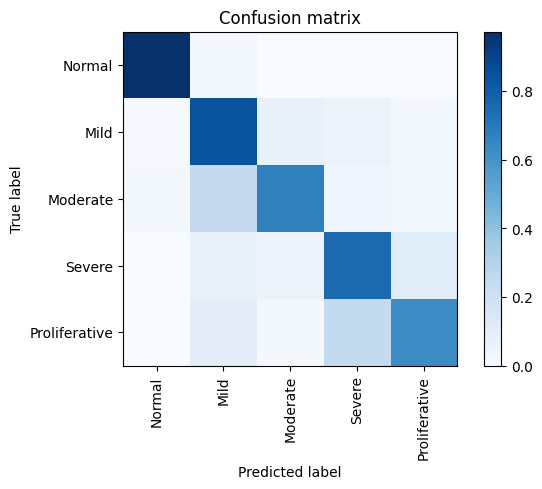

In [24]:
def plot_confusion_matrix(cm, target_names, title = 'Confusion matrix', cmap = plt.cm.Blues):
    plt.grid(False)
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation = 90)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
plot_confusion_matrix(cm = cm, target_names = diag_text)

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step


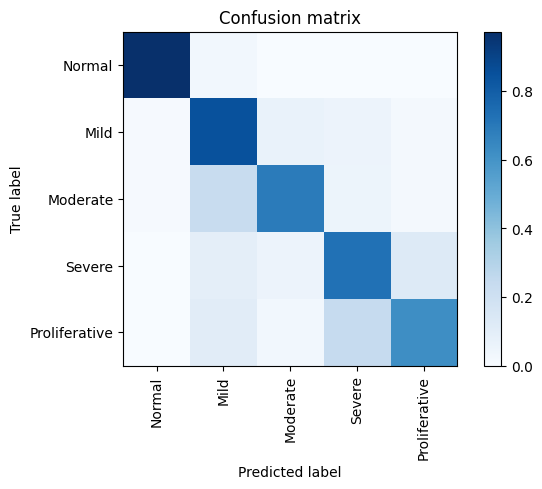

Confusion Matrix AFTER PHASE 1
[[0.97 0.03 0.   0.   0.  ]
 [0.01 0.85 0.07 0.06 0.02]
 [0.01 0.23 0.69 0.05 0.02]
 [0.   0.09 0.06 0.73 0.12]
 [0.   0.11 0.03 0.24 0.62]]
Classification Report
               precision    recall  f1-score   support

       Normal       0.98      0.97      0.98       110
         Mild       0.66      0.85      0.74       107
     Moderate       0.81      0.69      0.75       100
       Severe       0.69      0.73      0.71       106
Proliferative       0.78      0.62      0.69       100

     accuracy                           0.78       523
    macro avg       0.79      0.77      0.77       523
 weighted avg       0.79      0.78      0.78       523

Validation Cohen Kappa score: 0.860


In [33]:
# Xác suất dự đoán cho phase 1 2
# ---- DỰ ĐOÁN ----
validation_predictions_raw = model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
diag_text = ['Normal', 'Mild', 'Moderate', 'Severe','Proliferative']
# Lấy class có xác suất cao nhất
validation_predictions = np.argmax(validation_predictions_raw, axis=1)

# ---- GROUND TRUTH ----
validation_truth = val_generator.classes   # nhãn thật


np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plot_confusion_matrix(cm = cm, target_names = diag_text)
plt.show()

print('Confusion Matrix AFTER PHASE 1')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))

## Plot learning curves

## Evaluate the model

### Get validation predictions from the final model

### Plot some metrics

In [24]:
from tensorflow import keras

# load model phase 1
model_phase2 = keras.models.load_model("/kaggle/working/blindness_detector_best.keras",  custom_objects={"CBAM": CBAM}, compile=False)

y_pred1  = best_model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
y_pred2  = model.predict(
    val_generator,
    steps = val_generator.n // val_generator.batch_size + 1,
    verbose = 1
)
# nhãn thật
y_true = val_generator.classes   # (N,)


75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step


In [21]:
best_score = -1
best_w1 = None

# thử grid search từ 0.0 -> 1.0 với step = 0.05
for w1 in np.arange(0, 1.05, 0.05):
    w2 = 1 - w1
    y_ensemble = w1 * y_pred1 + w2 * y_pred2
    
    y_pred_labels = np.argmax(y_ensemble, axis=1)
    
    # metric: cohen_kappa hoặc accuracy
    score = cohen_kappa_score(y_true, y_pred_labels)  
    
    if score > best_score:
        best_score = score
        best_w1 = w1

print(f"Best w1={best_w1:.2f}, w2={1-best_w1:.2f}, Cohen Kappa={best_score:.4f}")

y_final = best_w1 * y_pred1 + (1-best_w1) * y_pred2
y_final_labels = np.argmax(y_final, axis=1)

print(classification_report(y_true, y_final_labels))

Best w1=0.60, w2=0.40, Cohen Kappa=0.7307
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       359
           1       0.63      0.89      0.74       214
           2       0.75      0.74      0.75       199
           3       0.70      0.66      0.68       212
           4       0.83      0.56      0.67       201

    accuracy                           0.79      1185
   macro avg       0.78      0.76      0.76      1185
weighted avg       0.80      0.79      0.79      1185



In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_meta = np.concatenate([y_pred1, y_pred2], axis=1)
y_meta = np.array(y_true)
if y_meta.ndim > 1:   # nếu one-hot
    y_meta = np.argmax(y_meta, axis=1)

oof_preds = np.zeros((len(y_meta), 5))  # 5 lớp

for train_idx, valid_idx in skf.split(X_meta, y_meta):
    X_train, X_valid = X_meta[train_idx], X_meta[valid_idx]
    y_train, y_valid = y_meta[train_idx], y_meta[valid_idx]

    clf = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05)
    clf.fit(X_train, y_train)

    oof_preds[valid_idx] = clf.predict_proba(X_valid)

oof_labels = np.argmax(oof_preds, axis=1)
print("Cohen Kappa (OOF):", cohen_kappa_score(y_meta, oof_labels))


Cohen Kappa (OOF): 0.768325719773322


In [28]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

# y_val: true labels (5925,)
# p1_val, p2_val: softmax probs từ Phase1 & Phase2 (shape: [5925, 4])


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros((len(y_meta), 5))  # lưu dự đoán out-of-fold

y_meta = np.array(y_meta)
for train_idx, valid_idx in skf.split(X_meta, y_meta):
    X_train, X_valid = X_meta[train_idx], X_meta[valid_idx]
    y_train, y_valid = y_meta[train_idx], y_meta[valid_idx]
    
    # Train meta-classifier
    clf = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05)
    clf.fit(X_train, y_train)
    
    # Predict OOF
    oof_preds[valid_idx] = clf.predict_proba(X_valid)

# Sau khi xong 5-fold, oof_preds là OOF prediction cho toàn bộ validation
oof_labels = np.argmax(oof_preds, axis=1)

print("Cohen Kappa (OOF):", cohen_kappa_score(y_meta, oof_labels))
print(classification_report(y_meta, oof_labels))
print(confusion_matrix(y_meta, oof_labels))


Cohen Kappa (OOF): 0.768325719773322
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       359
           1       0.79      0.78      0.78       214
           2       0.73      0.87      0.80       199
           3       0.70      0.67      0.69       212
           4       0.77      0.67      0.72       201

    accuracy                           0.82      1185
   macro avg       0.79      0.79      0.79      1185
weighted avg       0.82      0.82      0.82      1185

[[352   7   0   0   0]
 [  6 166  27  11   4]
 [  1  15 174   6   3]
 [  0  16  20 142  34]
 [  0   7  16  43 135]]


In [ ]:
# Predict đúng số lượng ảnh
steps = int(np.ceil(val_generator2.n / val_generator2.batch_size))

y_probs = model2.predict(val_generator2, steps=steps, verbose=1)

# Vì model output sigmoid → xác suất
y_pred = np.argmax(y_probs, axis=1)

# Cắt đúng số lượng ground truth
y_pred = y_pred[:val_generator2.n]

# Ground truth
y_true = val_generator2.classes


print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

def plot_confusion_matrix(cm, target_names, title = 'Confusion matrix', cmap = plt.cm.Blues):
    plt.grid(False)
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation = 90)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plot_confusion_matrix(cm = cm, target_names = diag_text)
plt.show()

print('Confusion Matrix AFTER PHASE 1')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))

## Look at some predictions from the validation set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

def plot_confusion_matrix(cm, target_names, title = 'Confusion matrix', cmap = plt.cm.Blues):
    plt.grid(False)
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation = 90)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plot_confusion_matrix(cm = cm, target_names = diag_text)
plt.show()

print('Confusion Matrix AFTER PHASE 2')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

def plot_confusion_matrix(cm, target_names, title = 'Confusion matrix', cmap = plt.cm.Blues):
    plt.grid(False)
    plt.imshow(cm, interpolation = 'nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation = 90)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

np.set_printoptions(precision = 2)
cm = confusion_matrix(validation_truth, validation_predictions)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plot_confusion_matrix(cm = cm, target_names = diag_text)
plt.show()

print('Confusion Matrix AFTER PHASE 3')
print(cm)

print('Classification Report')
print(classification_report(validation_truth, validation_predictions, target_names = diag_text))

print("Validation Cohen Kappa score: %.3f" % cohen_kappa_score(validation_predictions, validation_truth, weights = 'quadratic'))

In [ ]:
def plot_image(prediction_array, predicted_label, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap = plt.cm.binary)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(diag_text[predicted_label], 100 * np.max(prediction_array), diag_text[true_label]), color = color)

def plot_prediction(prediction_array, predicted_label, true_label):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(5), prediction_array, color = "#777777")
    plt.ylim([0, 1]) 
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')
  
# Plot some validation images, their predicted label, and the true label
# Color correct predictions in blue, incorrect predictions in red
plt.figure(figsize=(24, 6))
num_cols = 4
num_rows = 4
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(validation_predictions_raw[i], validation_predictions[i], validation_truth[i], x_val[i])
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_prediction(validation_predictions_raw[i], validation_predictions[i], validation_truth[i])
plt.show() 

## Make some predictions 

### Preprocess the test images

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Kích thước resize mong muốn
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

# Hàm crop ảnh (giữ lại vùng có nội dung)
def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:  # grayscale
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:  # RGB
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol        
        if mask.any():
            img1 = img[:,:,0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:,:,1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:,:,2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1,img2,img3], axis=-1)
        return img
    return img

# Hàm preprocess ảnh
def preprocess_image(image_path, sigmaX=10):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)        
    return cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  # convert lại BGR để lưu

In [ ]:
valid_csv = pd.read_csv("/kaggle/input/aptos2019/valid.csv")
print(valid_csv.head())

# ==== Load model ====


# ==== Predict toàn bộ ====
y_true, y_pred = [], []

val_dir = "/kaggle/input/aptos2019/val_images/val_images"

for idx, row in valid_csv.iterrows():
    img_id = row["id_code"]
    label = row["diagnosis"]

    img_path = os.path.join(val_dir, img_id + ".png")
    if not os.path.exists(img_path):
        print(f"Ảnh không tồn tại: {img_path}")
        continue

    img = preprocess_image(img_path)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)   # (1,224,224,3)

    pred = best_model.predict(img, verbose=0)
    pred_class = np.argmax(pred, axis=1)[0]

    y_true.append(label)
    y_pred.append(pred_class)

# ==== Evaluate ====
print("Accuracy:", accuracy_score(y_true, y_pred))
print("QWK:", cohen_kappa_score(y_true, y_pred, weights="quadratic"))
print(classification_report(y_true, y_pred))

In [ ]:
x_train = None
x_val = None
print("Preprocessing test images...")
!mkdir 'test_images_preprocessed/'
for i, image_id in enumerate(tqdm(test_df['id_code'])):
    image = preprocess_image(f'../input/aptos2019-blindness-detection/test_images/{image_id}')    
    cv2.imwrite(f'./test_images_preprocessed/{image_id}', image)
    

In [ ]:
test_datagen = ImageDataGenerator()
test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    directory = "./test_images_preprocessed/",
    x_col = "id_code",
    target_size = (IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size = 1,
    shuffle = False,
    class_mode = None)

y_test = model.predict_generator(test_generator) > 0.5
y_test = y_test.astype(int).sum(axis = 1) - 1

### Check out the class distribution in the predicitons compared to the traing data

In [ ]:
unique, counts = np.unique(y_test, return_counts = True)
plt.bar(unique, counts)

unique, counts = np.unique(validation_truth, return_counts = True)
plt.bar(unique, counts)

plt.title('Class Frequency Training and Predictions')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [ ]:
## COMPLETED